In [ ]:
import pandas as pd
import geopandas as gpd
import numpy as np
from shapely.geometry import Point

# =========================================================
# 0. HELPERS
# =========================================================

def clean_cols(df):
    df = df.copy()
    df.columns = (
        pd.Index(df.columns)
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace(r"[^a-z0-9]+", "_", regex=True)
        .str.strip("_")
    )
    return df

def find_col(df, candidates):
    cols = set(df.columns)
    for c in candidates:
        if c in cols:
            return c
    return None

# =========================================================
# 1. LOAD BASE DATA
# =========================================================

lsoa = gpd.read_file("master_lsoa.gpkg", layer="master_lsoa")
bus_stops = pd.read_csv("bus-stops.csv")
localities = pd.read_excel("bus-stops-suggested-localities (5).xlsx", sheet_name="Sheet1")
rm077 = pd.read_csv("RM077-2021-4.csv")

lsoa = clean_cols(lsoa)
bus_stops = clean_cols(bus_stops)
localities = clean_cols(localities)
rm077 = clean_cols(rm077)

# ensure projected CRS
if lsoa.crs is None or lsoa.crs.to_epsg() != 27700:
    lsoa = lsoa.to_crs(epsg=27700)

# =========================================================
# 2. BUILD GEOMETRY FOR BUS STOPS / LOCALITIES
# =========================================================

bus_e = find_col(bus_stops, ["location_easting"])
bus_n = find_col(bus_stops, ["location_northing"])

if bus_e is None or bus_n is None:
    raise ValueError("Could not find easting/northing columns in bus-stops.csv")

bus_gdf = gpd.GeoDataFrame(
    bus_stops.copy(),
    geometry=gpd.points_from_xy(bus_stops[bus_e], bus_stops[bus_n]),
    crs="EPSG:27700"
)

loc_e = find_col(localities, ["location_easting"])
loc_n = find_col(localities, ["location_northing"])

if loc_e is None or loc_n is None:
    raise ValueError("Could not find easting/northing columns in localities file")

localities_gdf = gpd.GeoDataFrame(
    localities.copy(),
    geometry=gpd.points_from_xy(localities[loc_e], localities[loc_n]),
    crs="EPSG:27700"
)

# =========================================================
# 3. BASIC BUS STOP ENRICHMENT TO LSOA
# =========================================================

lsoa_id = find_col(lsoa, ["lsoa_code"])
if lsoa_id is None:
    raise ValueError("Could not find lsoa_code in master_lsoa.gpkg")

bus_join = gpd.sjoin(
    bus_gdf,
    lsoa[[lsoa_id, "geometry"]],
    how="left",
    predicate="within"
)

# identify useful bus columns if present
virtual_col = find_col(bus_join, ["virtual_bus_stop"])
heading_col = find_col(bus_join, ["heading"])
stop_area_col = find_col(bus_join, ["stop_area"])
bus_code_col = find_col(bus_join, ["bus_stop_code", "stop_code_lbsl"])

bus_agg_parts = []

# total stop count
bus_count = (
    bus_join.groupby(lsoa_id)
    .size()
    .rename("bus_stop_count")
    .reset_index()
)
bus_agg_parts.append(bus_count)

# unique physical stop codes
if bus_code_col is not None:
    bus_unique = (
        bus_join.groupby(lsoa_id)[bus_code_col]
        .nunique()
        .rename("bus_stop_unique_count")
        .reset_index()
    )
    bus_agg_parts.append(bus_unique)

# mean heading
if heading_col is not None:
    # Convert 'heading_col' to numeric, coercing errors, before calculating mean
    bus_join[heading_col] = pd.to_numeric(bus_join[heading_col], errors='coerce')
    bus_heading = (
        bus_join.groupby(lsoa_id)[heading_col]
        .mean()
        .rename("bus_heading_mean")
        .reset_index()
    )
    bus_agg_parts.append(bus_heading)

# mean stop area
if stop_area_col is not None:
    # Convert 'stop_area_col' to numeric, coercing errors, before calculating mean
    bus_join[stop_area_col] = pd.to_numeric(bus_join[stop_area_col], errors='coerce')
    bus_area = (
        bus_join.groupby(lsoa_id)[stop_area_col]
        .mean()
        .rename("bus_stop_area_mean")
        .reset_index()
    )
    bus_agg_parts.append(bus_area)

# virtual stop share
if virtual_col is not None:
    bus_virtual = (
        bus_join.groupby(lsoa_id)[virtual_col]
        .mean()
        .rename("virtual_bus_stop_share")
        .reset_index()
    )
    bus_agg_parts.append(bus_virtual)

# merge all bus aggregates
bus_lsoa = bus_agg_parts[0]
for df_part in bus_agg_parts[1:]:
    bus_lsoa = bus_lsoa.merge(df_part, on=lsoa_id, how="outer")

lsoa = lsoa.merge(bus_lsoa, on=lsoa_id, how="left")

# fill sensible defaults
for c in [
    "bus_stop_count",
    "bus_stop_unique_count",
    "bus_heading_mean",
    "bus_stop_area_mean",
    "virtual_bus_stop_share"
]:
    if c in lsoa.columns:
        lsoa[c] = lsoa[c].fillna(0)

# density measures
area_col = find_col(lsoa, ["area_km2"])
if area_col is not None:
    lsoa["bus_stop_density_per_km2"] = np.where(
        lsoa[area_col] > 0,
        lsoa["bus_stop_count"] / lsoa[area_col],
        np.nan
    )
else:
    lsoa["bus_stop_density_per_km2"] = np.nan

# =========================================================
# 4. DISTANCE TO NEAREST BUS STOP
# =========================================================

# use centroids for neighbourhood-level access proxy
lsoa_cent = lsoa[[lsoa_id, "geometry"]].copy()
lsoa_cent["geometry"] = lsoa_cent.geometry.centroid

nearest = gpd.sjoin_nearest(
    lsoa_cent,
    bus_gdf[[bus_code_col, "geometry"]] if bus_code_col is not None else bus_gdf[["geometry"]],
    how="left",
    distance_col="dist_to_nearest_bus_stop_m"
)

nearest_dist = nearest[[lsoa_id, "dist_to_nearest_bus_stop_m"]].drop_duplicates(subset=[lsoa_id])
lsoa = lsoa.merge(nearest_dist, on=lsoa_id, how="left")

# =========================================================
# 5. SUGGESTED LOCALITY ENRICHMENT
# =========================================================

loc_join = gpd.sjoin(
    localities_gdf,
    lsoa[[lsoa_id, "geometry"]],
    how="left",
    predicate="within"
)

locality_name_col = find_col(loc_join, ["suggested_locality"])
locality_id_col = find_col(loc_join, ["locality_id"])
borough_col_loc = find_col(loc_join, ["borough"])

loc_parts = []

# count locality-tagged stops in each LSOA
loc_count = (
    loc_join.groupby(lsoa_id)
    .size()
    .rename("locality_stop_count")
    .reset_index()
)
loc_parts.append(loc_count)

# number of distinct localities touching an LSOA
if locality_id_col is not None:
    loc_nunique = (
        loc_join.groupby(lsoa_id)[locality_id_col]
        .nunique()
        .rename("distinct_locality_count")
        .reset_index()
    )
    loc_parts.append(loc_nunique)

# modal locality name per LSOA
if locality_name_col is not None:
    modal_locality = (
        loc_join.groupby([lsoa_id, locality_name_col])
        .size()
        .reset_index(name="n")
        .sort_values([lsoa_id, "n"], ascending=[True, False])
        .drop_duplicates(subset=[lsoa_id])
        [[lsoa_id, locality_name_col]]
        .rename(columns={locality_name_col: "dominant_suggested_locality"})
    )
    loc_parts.append(modal_locality)

loc_lsoa = loc_parts[0]
for df_part in loc_parts[1:]:
    loc_lsoa = loc_lsoa.merge(df_part, on=lsoa_id, how="outer")

lsoa = lsoa.merge(loc_lsoa, on=lsoa_id, how="left")

for c in ["locality_stop_count", "distinct_locality_count"]:
    if c in lsoa.columns:
        lsoa[c] = lsoa[c].fillna(0)

if area_col is not None:
    lsoa["locality_stop_density_per_km2"] = np.where(
        lsoa[area_col] > 0,
        lsoa["locality_stop_count"] / lsoa[area_col],
        np.nan
    )
else:
    lsoa["locality_stop_density_per_km2"] = np.nan

# =========================================================
# 6. BOROUGH-LEVEL COMMUTING ENRICHMENT FROM RM077
# =========================================================

# RM077 is lower-tier-local-authority level, not LSOA level.
# So we aggregate useful borough-level commuting structure and merge to LSOAs by LAD code.

lad_code_lsoa = find_col(lsoa, [
    "local_authority_district_code_2019",
    "local_authority_district_code"
])

lad_name_lsoa = find_col(lsoa, [
    "local_authority_district_name_2019",
    "local_authority_district_name"
])

rm_lad_code = find_col(rm077, ["lower_tier_local_authorities_code"])
rm_method = find_col(rm077, ["method_used_to_travel_to_workplace_12_categories"])
rm_distance = find_col(rm077, ["distance_travelled_to_work_5_categories"])
rm_obs = find_col(rm077, ["observation"])

if rm_lad_code and rm_method and rm_distance and rm_obs and lad_code_lsoa:
    rm = rm077.copy()

    # total observations by LAD
    rm_total = (
        rm.groupby(rm_lad_code)[rm_obs]
        .sum()
        .rename("borough_commute_obs_total")
        .reset_index()
    )

    # public transport-related travel modes
    pt_keywords = ["bus", "train", "underground", "metro", "tram"]
    rm["is_public_transport_mode"] = rm[rm_method].astype(str).str.lower().apply(
        lambda x: int(any(k in x for k in pt_keywords))
    )

    rm_pt = (
        rm.groupby([rm_lad_code, "is_public_transport_mode"])[rm_obs]
        .sum()
        .reset_index()
    )

    rm_pt_wide = (
        rm_pt.pivot(index=rm_lad_code, columns="is_public_transport_mode", values=rm_obs)
        .fillna(0)
        .rename(columns={0: "borough_non_pt_commute_obs", 1: "borough_pt_commute_obs"})
        .reset_index()
    )

    # longer-distance travel proxy
    long_keywords = ["10km", "30km", "longer", "20km", "40km"]
    rm["is_long_distance_band"] = rm[rm_distance].astype(str).str.lower().apply(
        lambda x: int(any(k in x for k in long_keywords))
    )

    rm_long = (
        rm.groupby([rm_lad_code, "is_long_distance_band"])[rm_obs]
        .sum()
        .reset_index()
    )

    rm_long_wide = (
        rm_long.pivot(index=rm_lad_code, columns="is_long_distance_band", values=rm_obs)
        .fillna(0)
        .rename(columns={0: "borough_shorter_commute_obs", 1: "borough_longer_commute_obs"})
        .reset_index()
    )

    borough_commute = rm_total.merge(rm_pt_wide, on=rm_lad_code, how="left")
    borough_commute = borough_commute.merge(rm_long_wide, on=rm_lad_code, how="left")

    borough_commute["borough_pt_commute_share"] = np.where(
        borough_commute["borough_commute_obs_total"] > 0,
        borough_commute["borough_pt_commute_obs"] / borough_commute["borough_commute_obs_total"],
        np.nan
    )

    borough_commute["borough_long_distance_share"] = np.where(
        borough_commute["borough_commute_obs_total"] > 0,
        borough_commute["borough_longer_commute_obs"] / borough_commute["borough_commute_obs_total"],
        np.nan
    )

    lsoa = lsoa.merge(
        borough_commute,
        left_on=lad_code_lsoa,
        right_on=rm_lad_code,
        how="left"
    )

# =========================================================
# 7. OPTIONAL DERIVED ACCESS-GAP VARIABLES
# =========================================================

dist_station_col = find_col(lsoa, ["dist_to_station_m"])
ptal_col = find_col(lsoa, ["mean_ptal_ai"])
popden_col = find_col(lsoa, ["pop_density_2021"])
employment_col = find_col(lsoa, ["employment_rate"])

if dist_station_col and ptal_col:
    lsoa["bus_vs_rail_gap_index"] = (
        lsoa["bus_stop_density_per_km2"].fillna(0)
        * lsoa[dist_station_col].fillna(0)
        / (lsoa[ptal_col].fillna(0) + 1)
    )

if popden_col:
    lsoa["bus_stop_per_1000_density_units"] = np.where(
        lsoa[popden_col] > 0,
        lsoa["bus_stop_count"] / lsoa[popden_col] * 1000,
        np.nan
    )

if employment_col and "bus_stop_count" in lsoa.columns:
    lsoa["bus_stop_count_x_employment_rate"] = (
        lsoa["bus_stop_count"].fillna(0) * lsoa[employment_col].fillna(0)
    )

# =========================================================
# 8. SAVE ENRICHED DATASET
# =========================================================

lsoa.to_file("master_lsoa_enriched.gpkg", layer="master_lsoa_enriched", driver="GPKG")
lsoa.drop(columns="geometry").to_csv("master_lsoa_enriched.csv", index=False)

print("Done.")
print("Saved:")
print(" - master_lsoa_enriched.gpkg")
print(" - master_lsoa_enriched.csv")

# quick preview of newly added columns
new_cols = [
    "bus_stop_count",
    "bus_stop_unique_count",
    "bus_stop_area_mean",
    "virtual_bus_stop_share",
    "bus_stop_density_per_km2",
    "dist_to_nearest_bus_stop_m",
    "locality_stop_count",
    "distinct_locality_count",
    "dominant_suggested_locality",
    "locality_stop_density_per_km2",
    "borough_commute_obs_total",
    "borough_pt_commute_obs",
    "borough_pt_commute_share",
    "borough_long_distance_share",
    "bus_vs_rail_gap_index",
    "bus_stop_per_1000_density_units",
    "bus_stop_count_x_employment_rate"
]

print("\nAdded columns found:")
print([c for c in new_cols if c in lsoa.columns])

preview_cols = [c for c in [
    lsoa_id,
    "bus_stop_count",
    "bus_stop_density_per_km2",
    "dist_to_nearest_bus_stop_m",
    "locality_stop_count",
    "dominant_suggested_locality",
    "borough_pt_commute_share",
    "borough_long_distance_share",
    "bus_vs_rail_gap_index"
] if c in lsoa.columns]

print("\nPreview:")
print(lsoa[preview_cols].head(10))

Done.
Saved:
 - master_lsoa_enriched.gpkg
 - master_lsoa_enriched.csv

Added columns found:
['bus_stop_count', 'bus_stop_unique_count', 'bus_stop_area_mean', 'virtual_bus_stop_share', 'bus_stop_density_per_km2', 'dist_to_nearest_bus_stop_m', 'locality_stop_count', 'distinct_locality_count', 'dominant_suggested_locality', 'locality_stop_density_per_km2', 'borough_commute_obs_total', 'borough_pt_commute_obs', 'borough_pt_commute_share', 'borough_long_distance_share', 'bus_vs_rail_gap_index', 'bus_stop_per_1000_density_units', 'bus_stop_count_x_employment_rate']

Preview:
   lsoa_code  bus_stop_count  bus_stop_density_per_km2  \
0  E01000001             6.0                 38.024058   
1  E01000002             2.0                 12.129879   
2  E01000003             0.0                  0.000000   
3  E01000005             9.0                 42.312970   
4  E01000006             0.0                  0.000000   
5  E01000007             3.0                 14.239167   
6  E01000008      

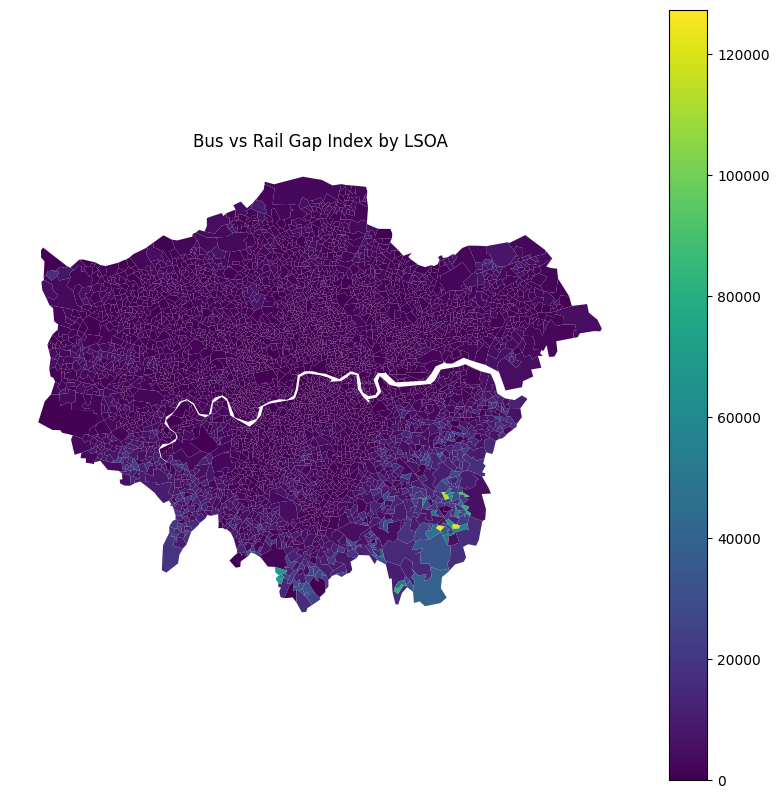

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

gdf = gpd.read_file("master_lsoa_enriched.gpkg", layer="master_lsoa_enriched")

fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(
    column="bus_vs_rail_gap_index",
    cmap="viridis",
    legend=True,
    linewidth=0,
    ax=ax
)
ax.set_title("Bus vs Rail Gap Index by LSOA")
ax.axis("off")
plt.show()

<Axes: >

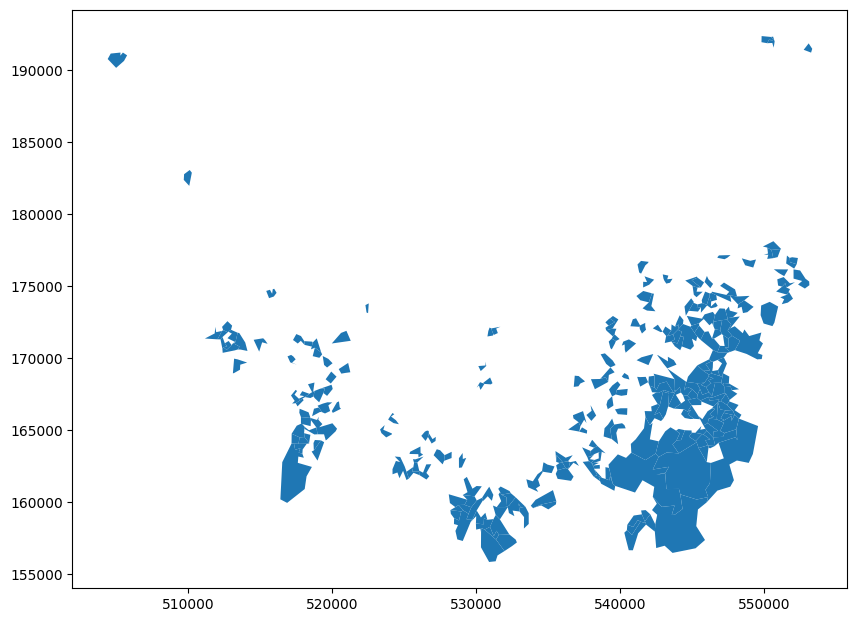

In [ ]:
threshold = gdf["bus_vs_rail_gap_index"].quantile(0.95)

hotspots = gdf[gdf["bus_vs_rail_gap_index"] > threshold]

hotspots.plot(figsize=(10,10))

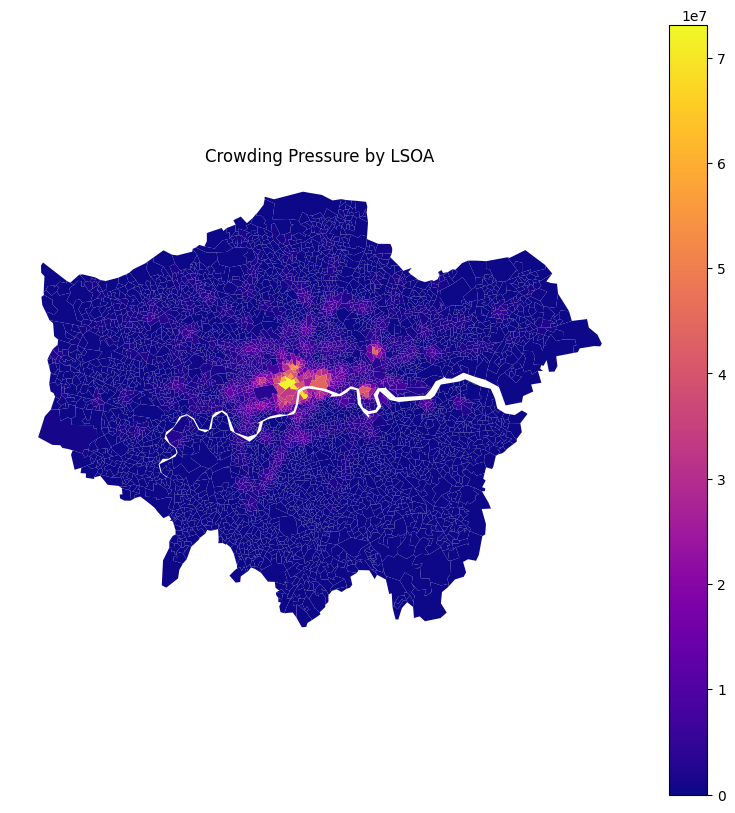

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(
    column="crowding_pressure",
    cmap="plasma",
    legend=True,
    linewidth=0,
    ax=ax
)
ax.set_title("Crowding Pressure by LSOA")
ax.axis("off")
plt.show()


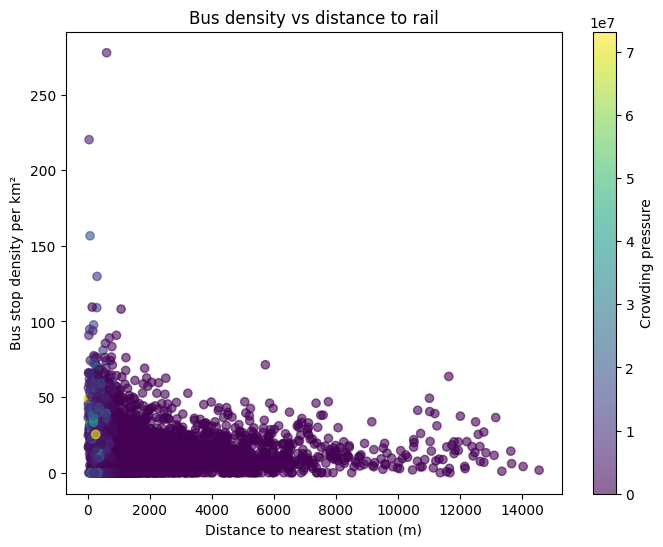

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = gdf.drop(columns="geometry").copy()

plot_df = df[[
    "dist_to_station_m",
    "bus_stop_density_per_km2",
    "crowding_pressure"
]].dropna()

plt.figure(figsize=(8,6))
plt.scatter(
    plot_df["dist_to_station_m"],
    plot_df["bus_stop_density_per_km2"],
    c=plot_df["crowding_pressure"],
    alpha=0.6
)
plt.xlabel("Distance to nearest station (m)")
plt.ylabel("Bus stop density per km²")
plt.title("Bus density vs distance to rail")
plt.colorbar(label="Crowding pressure")
plt.show()

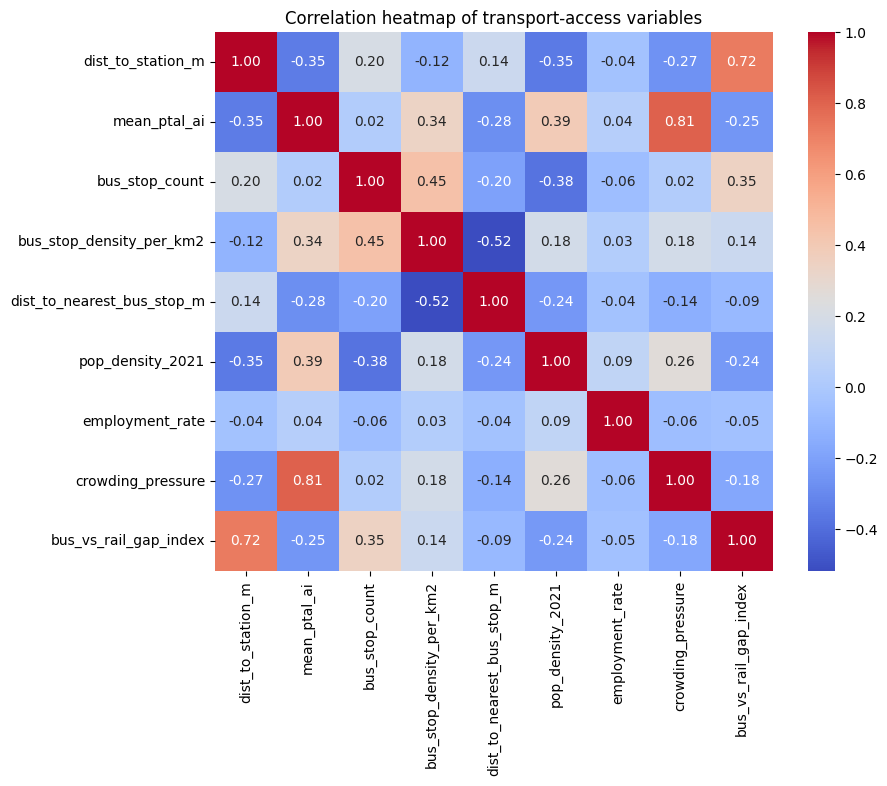

In [ ]:
import seaborn as sns

cols = [
    "dist_to_station_m",
    "mean_ptal_ai",
    "bus_stop_count",
    "bus_stop_density_per_km2",
    "dist_to_nearest_bus_stop_m",
    "pop_density_2021",
    "employment_rate",
    "crowding_pressure",
    "bus_vs_rail_gap_index"
]

corr = df[cols].corr()

plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation heatmap of transport-access variables")
plt.show()

In [ ]:
import pandas as pd
import geopandas as gpd
import numpy as np
import requests
import time
import re
from shapely.geometry import Point
import os # Import the os module to check for file existence

# =========================================================
# USER SETTINGS
# =========================================================

BUS_STATS_FILE = "2024-25-annual-bus-stats.xlsx"
LSOA_FILE = "master_lsoa_enriched.gpkg"
LSOA_LAYER = "master_lsoa_enriched"

# Optional TfL API credentials
APP_ID = ""   # e.g. "your_app_id"
APP_KEY = ""  # e.g. "your_app_key"

# Output files
ROUTE_PRESSURE_LONG_FILE = "route_pressure_long.csv"
ROUTE_PRESSURE_SUMMARY_FILE = "route_pressure_summary.csv"
ROUTE_STOP_LOOKUP_FILE = "route_stop_lookup_from_tfl_api.csv"
ROUTE_STOP_ERRORS_FILE = "route_stop_lookup_errors.csv"
STOP_PRESSURE_FILE = "stop_pressure.csv"
OUTPUT_GPKG = "master_lsoa_enriched_with_route_pressure.gpkg"
OUTPUT_LAYER = "master_lsoa_enriched_with_route_pressure"
OUTPUT_CSV = "master_lsoa_enriched_with_route_pressure.csv"

# =========================================================
# HELPERS
# =========================================================

def clean_cols(df):
    df = df.copy()
    df.columns = (
        pd.Index(df.columns)
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace(r"[\n\r]+", " ", regex=True)
        .str.replace(r"[^a-z0-9]+", "_", regex=True)
        .str.strip("_")
    )
    return df

def find_col(df, candidates):
    cols = set(df.columns)
    for c in candidates:
        if c in cols:
            return c
    return None

def safe_numeric(series):
    return pd.to_numeric(series, errors="coerce")

# =========================================================
# STEP 1: READ BUS STATS WORKBOOK AND BUILD ROUTE PRESSURE
# =========================================================

print("Loading bus stats workbook...")
xls = pd.ExcelFile(BUS_STATS_FILE)
print("Sheets found:")
print(xls.sheet_names)

def load_year_sheet(file, sheet_name):
    """
    Attempts to parse a yearly bus stats sheet.
    Assumes there are metadata rows above the actual table.
    Adjust header_row if needed.
    """
    raw = pd.read_excel(file, sheet_name=sheet_name, header=None)

    # Most likely header row based on your earlier workbook screenshots.
    # If parsing fails, try 1 or 2 manually.
    candidate_header_rows = [0, 1, 2, 3]

    for header_row in candidate_header_rows:
        try:
            tmp = raw.iloc[header_row + 1:].copy()
            tmp.columns = raw.iloc[header_row].tolist()
            tmp = clean_cols(tmp)

            # Debugging: print cleaned columns
            # print(f"Sheet '{sheet_name}' (header_row={header_row}) cleaned columns: {tmp.columns.tolist()}")

            route_col_found = find_col(tmp, ["route"])

            usage_col_found = None
            for col in tmp.columns:
                if "usage_recorded" in col:
                    usage_col_found = col
                    break

            km_col_found = None
            for col in tmp.columns:
                if "bus_km_operated" in col:
                    km_col_found = col
                    break

            if route_col_found and usage_col_found and km_col_found:
                out = tmp[[route_col_found, usage_col_found, km_col_found]].copy()
                out.columns = ["route", "usage_recorded", "bus_km_operated"]

                out["route"] = out["route"].astype(str).str.strip()
                out["usage_recorded"] = safe_numeric(out["usage_recorded"])
                out["bus_km_operated"] = safe_numeric(out["bus_km_operated"])
                out["year"] = str(sheet_name).strip()

                out = out.dropna(subset=["route", "usage_recorded", "bus_km_operated"])
                out = out[out["route"] != ""]
                return out
        except Exception:
            pass

    raise ValueError(f"Could not parse sheet: {sheet_name}")

year_sheets = [s for s in xls.sheet_names if re.search(r"\d{4}-\d{4}", str(s))]

frames = []
for s in year_sheets:
    try:
        df_year = load_year_sheet(BUS_STATS_FILE, s)
        frames.append(df_year)
        print(f"Loaded {s}: {len(df_year)} rows")
    except Exception as e:
        print(f"Skipped {s}: {e}")

if not frames:
    raise ValueError("No yearly sheets could be parsed from the workbook.")

route_pressure_long = pd.concat(frames, ignore_index=True)

# Route pressure proxy: usage per bus-km
route_pressure_long["route_pressure"] = np.where(
    route_pressure_long["bus_km_operated"] > 0,
    route_pressure_long["usage_recorded"] / route_pressure_long["bus_km_operated"],
    np.nan
)

# Clean route labels a bit
route_pressure_long["route"] = route_pressure_long["route"].astype(str).str.strip()

route_pressure_long.to_csv(ROUTE_PRESSURE_LONG_FILE, index=False)
print(f"Saved {ROUTE_PRESSURE_LONG_FILE}")

route_pressure_summary = (
    route_pressure_long.groupby("route")
    .agg(
        years_observed=("year", "nunique"),
        avg_usage_recorded=("usage_recorded", "mean"),
        avg_bus_km_operated=("bus_km_operated", "mean"),
        avg_route_pressure=("route_pressure", "mean"),
        max_route_pressure=("route_pressure", "max"),
        latest_usage_recorded=("usage_recorded", "last"),
        latest_bus_km_operated=("bus_km_operated", "last"),
        latest_route_pressure=("route_pressure", "last"),
    )
    .reset_index()
    .sort_values("avg_route_pressure", ascending=False)
)

route_pressure_summary.to_csv(ROUTE_PRESSURE_SUMMARY_FILE, index=False)
print(f"Saved {ROUTE_PRESSURE_SUMMARY_FILE}")

# =========================================================
# STEP 2: DOWNLOAD ROUTE->STOP LOOKUP FROM TFL API
# =========================================================

print("\nFetching route-stop lookup from TfL API...")

if os.path.exists(ROUTE_STOP_LOOKUP_FILE):
    print(f"Found existing {ROUTE_STOP_LOOKUP_FILE}. Loading from file...")
    route_stop_lookup = pd.read_csv(ROUTE_STOP_LOOKUP_FILE)
    errors = [] # Assume no new errors if loading existing file
else:
    print("Route-stop lookup file not found. Fetching from TfL API...")
    routes = route_pressure_summary["route"].dropna().astype(str).str.strip().unique().tolist()

    BASE_URL = "https://api.tfl.gov.uk/Line/{route}/Route/Sequence/{direction}"

    def fetch_route_sequence(route, direction):
        url = BASE_URL.format(route=route, direction=direction)

        params = {}
        if APP_ID:
            params["app_id"] = APP_ID
        if APP_KEY:
            params["app_key"] = APP_KEY

        try:
            r = requests.get(url, params=params, timeout=30)
            if r.status_code != 200:
                return None, f"{route} {direction} failed with status {r.status_code}"
            return r.json(), None
        except Exception as e:
            return None, f"{route} {direction} failed with error: {e}"

    def parse_sequence_json(js, route, direction):
        rows = []
        seqs = js.get("stopPointSequences", [])

        for seq_block in seqs:
            seq_name = seq_block.get("name")
            stop_points = seq_block.get("stopPoint", [])

            for i, sp in enumerate(stop_points, start=1):
                rows.append({
                    "route": route,
                    "direction": direction,
                    "sequence_block": seq_name,
                    "sequence": i,
                    "stop_id": sp.get("id"),
                    "stop_name": sp.get("name"),
                    "lat": sp.get("lat"),
                    "lon": sp.get("lon"),
                    "indicator": sp.get("indicator"),
                    "stop_letter": sp.get("stopLetter"),
                    "towards": sp.get("towards"),
                })
        return rows

    all_rows = []
    errors = []

    for idx, route in enumerate(routes, start=1):
        for direction in ["outbound", "inbound"]:
            js, err = fetch_route_sequence(route, direction)
            if err:
                errors.append(err)
                continue

            rows = parse_sequence_json(js, route, direction)
            all_rows.extend(rows)

            # polite pause
            time.sleep(0.1)

        if idx % 25 == 0:
            print(f"Processed {idx} routes")

    route_stop_lookup = pd.DataFrame(all_rows)

    if route_stop_lookup.empty:
        raise ValueError("No route-stop data returned from the TfL API.")

    route_stop_lookup = route_stop_lookup.drop_duplicates(
        subset=["route", "direction", "sequence_block", "stop_id", "sequence"]
    )

    route_stop_lookup.to_csv(ROUTE_STOP_LOOKUP_FILE, index=False)
    print(f"Saved {ROUTE_STOP_LOOKUP_FILE}")

    if errors:
        pd.DataFrame({"error": errors}).to_csv(ROUTE_STOP_ERRORS_FILE, index=False)
        print(f"Saved {ROUTE_STOP_ERRORS_FILE}")

# =========================================================
# STEP 3: ATTACH ROUTE PRESSURE TO ROUTE-STOP LOOKUP
# =========================================================

route_stop_pressure = route_stop_lookup.merge(
    route_pressure_summary[["route", "avg_route_pressure", "max_route_pressure", "latest_route_pressure"]],
    on="route",
    how="left"
)

# =========================================================
# STEP 4: AGGREGATE ROUTE PRESSURE TO STOP LEVEL
# =========================================================

stop_pressure = (
    route_stop_pressure.groupby("stop_id")
    .agg(
        routes_served=("route", "nunique"),
        mean_route_pressure=("avg_route_pressure", "mean"),
        max_route_pressure=("max_route_pressure", "max"),
        latest_route_pressure=("latest_route_pressure", "mean"),
        lat=("lat", "first"),
        lon=("lon", "first"),
        stop_name=("stop_name", "first"),
    )
    .reset_index()
)

stop_pressure.to_csv(STOP_PRESSURE_FILE, index=False)
print(f"Saved {STOP_PRESSURE_FILE}")

# =========================================================
# STEP 5: TURN STOPS INTO GEODATAFRAME
# =========================================================

stop_pressure_gdf = gpd.GeoDataFrame(
    stop_pressure,
    geometry=gpd.points_from_xy(stop_pressure["lon"], stop_pressure["lat"]),
    crs="EPSG:4326"
).to_crs(epsg=27700)

# =========================================================
# STEP 6: LOAD ENRICHED LSOA DATASET
# =========================================================

print("\nLoading enriched LSOA dataset...")
lsoa = gpd.read_file(LSOA_FILE, layer=LSOA_LAYER)
lsoa = clean_cols(lsoa)

if lsoa.crs is None or lsoa.crs.to_epsg() != 27700:
    lsoa = lsoa.to_crs(epsg=27700)

lsoa_id = find_col(lsoa, ["lsoa_code"])
if lsoa_id is None:
    raise ValueError("Could not find lsoa_code in LSOA dataset.")

# =========================================================
# STEP 7: SPATIALLY JOIN STOPS TO LSOAS
# =========================================================

joined = gpd.sjoin(
    stop_pressure_gdf,
    lsoa[[lsoa_id, "geometry"]],
    how="left",
    predicate="within"
)

# =========================================================
# STEP 8: AGGREGATE STOP PRESSURE TO LSOA LEVEL
# =========================================================

lsoa_route_pressure = (
    joined.groupby(lsoa_id)
    .agg(
        mean_stop_route_pressure=("mean_route_pressure", "mean"),
        max_stop_route_pressure=("max_route_pressure", "max"),
        latest_stop_route_pressure=("latest_route_pressure", "mean"),
        mean_routes_served=("routes_served", "mean"),
        max_routes_served=("routes_served", "max"),
        pressured_stop_count=("stop_id", "nunique"),
    )
    .reset_index()
)

lsoa = lsoa.merge(lsoa_route_pressure, on=lsoa_id, how="left")

# Fill missing where no stop pressure matched
for c in [
    "mean_stop_route_pressure",
    "max_stop_route_pressure",
    "latest_stop_route_pressure",
    "mean_routes_served",
    "max_routes_served",
    "pressured_stop_count"
]:
    if c in lsoa.columns:
        lsoa[c] = lsoa[c].fillna(0)

# =========================================================
# STEP 9: BUILD NEW CROWDING / PRESSURE VARIABLES
# =========================================================

# Existing useful cols if present
bus_density_col = find_col(lsoa, ["bus_stop_density_per_km2"])
dist_station_col = find_col(lsoa, ["dist_to_station_m"])
ptal_col = find_col(lsoa, ["mean_ptal_ai"])
popden_col = find_col(lsoa, ["pop_density_2021"])
employment_col = find_col(lsoa, ["employment_rate"])

# Main bus crowding proxy
if bus_density_col:
    lsoa["bus_crowding_proxy"] = (
        lsoa["mean_stop_route_pressure"].fillna(0) *
        lsoa[bus_density_col].fillna(0)
    )
else:
    lsoa["bus_crowding_proxy"] = lsoa["mean_stop_route_pressure"].fillna(0)

# Rail-bus pressure gap
if dist_station_col and ptal_col:
    lsoa["rail_bus_pressure_gap"] = (
        lsoa["mean_stop_route_pressure"].fillna(0) *
        lsoa[dist_station_col].fillna(0) /
        (lsoa[ptal_col].fillna(0) + 1)
    )
else:
    lsoa["rail_bus_pressure_gap"] = lsoa["mean_stop_route_pressure"].fillna(0)

# More complete station-need proxy
if dist_station_col and ptal_col and popden_col:
    lsoa["route_based_station_need"] = (
        lsoa["mean_stop_route_pressure"].fillna(0) *
        lsoa[dist_station_col].fillna(0) *
        lsoa[popden_col].fillna(0) /
        (lsoa[ptal_col].fillna(0) + 1)
    )
else:
    lsoa["route_based_station_need"] = lsoa["mean_stop_route_pressure"].fillna(0)

# Optional labour adjustment
if employment_col:
    lsoa["route_pressure_x_employment"] = (
        lsoa["mean_stop_route_pressure"].fillna(0) *
        lsoa[employment_col].fillna(0)
    )

# =========================================================
# STEP 10: SAVE ENRICHED OUTPUT
# =========================================================

lsoa.to_file(OUTPUT_GPKG, layer=OUTPUT_LAYER, driver="GPKG")
lsoa.drop(columns="geometry").to_csv(OUTPUT_CSV, index=False)

print("\nDone.")
print(f"Saved {OUTPUT_GPKG}")
print(f"Saved {OUTPUT_CSV}")

# =========================================================
# STEP 11: QUICK PREVIEW
# =========================================================

preview_cols = [c for c in [
    lsoa_id,
    "mean_stop_route_pressure",
    "max_stop_route_pressure",
    "latest_stop_route_pressure",
    "mean_routes_served",
    "pressured_stop_count",
    "bus_crowding_proxy",
    "rail_bus_pressure_gap",
    "route_based_station_need"
] if c in lsoa.columns]

print("\nPreview of new LSOA fields:")
print(lsoa[preview_cols].sort_values("route_based_station_need", ascending=False).head(15))

Loading bus stats workbook...
Sheets found:
['NOTES', '2010-2011', '2011-2012', '2012-2013', '2013-2014', '2014-2015', '2015-2016', '2016-2017 original & rebased', '2017-2018', '2018-2019', '2019-2020 52 and 48 weeks', '2020-2021 52 and 39 weeks', '2021-2022', '2022-2023', '2023-2024', '2024-2025']
Loaded 2010-2011: 665 rows
Loaded 2011-2012: 666 rows
Loaded 2012-2013: 671 rows
Loaded 2013-2014: 670 rows
Loaded 2014-2015: 666 rows
Loaded 2015-2016: 672 rows
Loaded 2016-2017 original & rebased: 687 rows
Loaded 2017-2018: 681 rows
Loaded 2018-2019: 679 rows
Loaded 2019-2020 52 and 48 weeks: 690 rows
Loaded 2020-2021 52 and 39 weeks: 665 rows
Loaded 2021-2022: 664 rows
Loaded 2022-2023: 664 rows
Loaded 2023-2024: 673 rows
Loaded 2024-2025: 667 rows
Saved route_pressure_long.csv
Saved route_pressure_summary.csv

Fetching route-stop lookup from TfL API...
Found existing route_stop_lookup_from_tfl_api.csv. Loading from file...
Saved stop_pressure.csv

Loading enriched LSOA dataset...

Done.


In [ ]:
import geopandas as gpd

# load geopackage
gdf = gpd.read_file("master_lsoa (1).gpkg")

# drop geometry for CSV
df = gdf.drop(columns="geometry")

# save csv
df.to_csv("master_lsoa_converted.csv", index=False)

print("CSV saved as master_lsoa_converted.csv")

CSV saved as master_lsoa_converted.csv


In [ ]:
df

,lsoa_code,lsoa_name,lat,long,dist_to_station_m,mean_ptal_ai,median_ptal_ai,min_ptal_ai,max_ptal_ai,mean_ptal_level,...,mean_stop_route_pressure,max_stop_route_pressure,latest_stop_route_pressure,mean_routes_served,max_routes_served,pressured_stop_count,bus_crowding_proxy,rail_bus_pressure_gap,route_based_station_need,route_pressure_x_employment
0,E01000001,City of London 001A,51.518169,-0.097150,204.518626,74.818060,76.150404,43.344686,97.664050,6b,...,3.875874,6.536193,3.695247,2.000000,3.0,7.0,147.376443,10.455139,1.188080e+05,2.452903
1,E01000002,City of London 001B,51.518829,-0.091970,220.345065,85.324898,88.899953,44.802674,102.127724,6b,...,2.656807,3.726686,2.602180,1.000000,1.0,2.0,32.226750,6.781524,4.111096e+04,1.780757
2,E01000003,City of London 001C,51.521740,-0.095330,215.995947,53.411383,54.114541,36.995870,66.989479,6b,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000e+00,0.000000
3,E01000005,City of London 001E,51.514690,-0.076280,74.720599,82.428912,86.649985,45.504887,104.154096,6b,...,2.842652,9.999199,2.786289,2.375000,5.0,8.0,120.281040,2.545936,1.477076e+04,1.409482
4,E01000006,Barking and Dagenham 016A,51.538750,0.089317,481.008545,24.153971,27.931273,2.836977,33.400903,5,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000e+00,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4989,E01035718,Westminster 019G,51.505589,-0.168450,703.416605,21.345578,18.360370,0.000000,58.416145,5,...,3.611952,5.906055,3.825990,2.200000,3.0,10.0,38.266947,113.700656,1.092777e+05,1.374640
4990,E01035719,Westminster 021F,51.492771,-0.126960,597.393054,17.095330,16.214325,8.159429,29.060556,4,...,3.849864,5.113939,3.862887,1.500000,2.0,2.0,138.520530,127.098086,1.740240e+06,2.304323
4991,E01035720,Westminster 021G,51.489971,-0.128770,300.894527,27.151005,27.575604,15.194949,39.850213,6a,...,4.194486,5.113939,4.194517,1.333333,2.0,3.0,174.488476,44.833137,5.137653e+05,2.612182
4992,E01035721,Westminster 023H,51.489651,-0.151920,372.836046,40.060264,42.324521,21.898905,56.923864,6b,...,4.974365,7.743498,4.928023,1.250000,2.0,4.0,214.729112,45.168307,4.845837e+05,2.610310
